In [19]:
import pandas as pd
import numpy as np

# ============================================================
# OPTION MOVIELENS 100K (943 utilisateurs, 1682 films)
# ============================================================

# Chemins des données MovieLens
movielens_path = "movielensData/ml-100k"

# Charger les données
ratings = pd.read_csv(
    f"{movielens_path}/u.data",
    sep='\t',
    names=['id_student', 'code_module', 'score', 'timestamp'],
    encoding='latin-1'
)

movies = pd.read_csv(
    f"{movielens_path}/u.item",
    sep='|',
    names=['code_module', 'title', 'release_date', 'video_release_date', 'imdb_url'] + 
          ['unknown', 'action', 'adventure', 'animation', 'childrens', 'comedy', 
           'crime', 'documentary', 'drama', 'fantasy', 'film_noir', 'horror', 
           'musical', 'mystery', 'romance', 'sci_fi', 'thriller', 'war', 'western'],
    encoding='latin-1'
)

# Adapté pour correspondre à la structure du code existant
clicks = ratings[['id_student', 'code_module', 'score']].copy()
clicks.rename(columns={'score': 'click_score'}, inplace=True)

# Note moyenne par utilisateur (pour simuler assess)
assess = ratings.groupby('id_student')['score'].mean().reset_index()
assess.rename(columns={'score': 'score'}, inplace=True)

# Fusion
student_vle = clicks
student_assess = assess

print("✅ MovieLens 100K chargé avec succès!")
print(f"  • Utilisateurs: {ratings['id_student'].nunique()}")
print(f"  • Films: {ratings['code_module'].nunique()}")
print(f"  • Notes: {len(ratings)}")
print(f"\n📽️ Exemples de films:")
print(movies[['code_module', 'title']].head(10).to_string(index=False))

✅ MovieLens 100K chargé avec succès!
  • Utilisateurs: 943
  • Films: 1682
  • Notes: 100000

📽️ Exemples de films:
 code_module                                                title
           1                                     Toy Story (1995)
           2                                     GoldenEye (1995)
           3                                    Four Rooms (1995)
           4                                    Get Shorty (1995)
           5                                       Copycat (1995)
           6 Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)
           7                                Twelve Monkeys (1995)
           8                                          Babe (1995)
           9                              Dead Man Walking (1995)
          10                                   Richard III (1995)


clics (engagement)

In [20]:
# Agrégation des clics (sum_click) par utilisateur et film
clicks = ratings.groupby(['id_student', 'code_module'])['score'].agg(['sum', 'count']).reset_index()
clicks.rename(columns={'sum': 'click_score', 'count': 'interactions'}, inplace=True)

notes (perofrmances)

In [21]:
# Scores moyens par utilisateur (sur MovieLens: 1-5)
assess = ratings.groupby('id_student')['score'].mean().reset_index()
assess.rename(columns={'score': 'avg_score'}, inplace=True)

score final (pseudo-rating)

In [22]:
# Fusion clicks + assess
df = clicks.merge(assess, on='id_student', how='left')

# Score final : 60% engagement (click_score) + 40% performance (score MovieLens)
df['rating'] = (df['click_score'] / df['click_score'].max()) * 0.6 + \
                (df['avg_score'] / 5) * 0.4  # MovieLens: 1-5 rating scale

print(f"✅ Dataset préparé:")
print(f"  • Interactions: {len(df)}")
print(f"  • Score moyen: {df['rating'].mean():.3f}")

✅ Dataset préparé:
  • Interactions: 100000
  • Score moyen: 0.706


Filtrage collaboratif (CF)

preparer dataset

split train test

Modele SVD

# PHASE 1 : Business Understanding
Définir le scénario de recommandation : "À chaque connexion, suggérer 5 cours personnalisés à l'apprenant"
Contraintes : cold start, popularité bias, diversité
Métriques : Hit@5, Coverage, RMSE

In [ ]:
# Métriques de recommandation

def hit_rate_at_k(y_true, y_pred, k=5):
    """Proportion d'utilisateurs ayant au moins un item pertinent dans les k premières"""
    y_pred = y_pred[:k]
    return 1.0 if any(x in y_true for x in y_pred) else 0.0


def coverage_at_k(y_pred, n_items, k=5):
    """Couverture du catalogue par les recommandations"""
    y_pred = y_pred[:k]
    return len(set(y_pred)) / n_items if n_items > 0 else 0.0


def rmse(y_true, y_pred):
    """Erreur quadratique moyenne"""
    return (((y_true - y_pred) ** 2).mean()) ** 0.5

print("✓ Métriques définies : RMSE, Hit@5, Coverage")

✓ Métriques définies : Precision@5, Recall@5, RMSE


# PHASE 2 : Data Understanding
Analyser la matrice utilisateurs-cours, densité, longue traîne, cold start

In [23]:
# Analyse de la matrice utilisateurs-cours
import numpy as np
import matplotlib.pyplot as plt

# Matrice user-item
user_item = df.pivot_table(index='id_student', 
                           columns='code_module', 
                           values='rating', 
                           fill_value=0)

# Statistiques
n_users = user_item.shape[0]
n_items = user_item.shape[1]
n_interactions = (user_item > 0).sum().sum()
sparsity = 1 - (n_interactions / (n_users * n_items))

print(f" Dataset Statistics:")
print(f"  • Utilisateurs : {n_users}")
print(f"  • Cours : {n_items}")
print(f"  • Interactions : {n_interactions}")
print(f"  • Densité : {100*(1-sparsity):.2f}%")
print(f"  • Sparsité : {100*sparsity:.2f}%")

# Cold start : utilisateurs avec peu d'interactions
interactions_per_user = (user_item > 0).sum(axis=1)
cold_start_users = (interactions_per_user < 3).sum()
print(f"\n  Cold Start Problem:")
print(f"  • Utilisateurs avec < 3 cours : {cold_start_users} ({100*cold_start_users/n_users:.1f}%)")

# Popularité : distribution des cours
interactions_per_item = (user_item > 0).sum(axis=0)
print(f"\n Popularité des cours:")
print(f"  • Cours médian suivi par : {interactions_per_item.median():.0f} utilisateurs")
print(f"  • Top 10 cours : {interactions_per_item.nlargest(10).sum()} / {n_interactions} interactions ({100*interactions_per_item.nlargest(10).sum()/n_interactions:.1f}%)")

 Dataset Statistics:
  • Utilisateurs : 943
  • Cours : 1682
  • Interactions : 100000
  • Densité : 6.30%
  • Sparsité : 93.70%

  Cold Start Problem:
  • Utilisateurs avec < 3 cours : 0 (0.0%)

 Popularité des cours:
  • Cours médian suivi par : 27 utilisateurs
  • Top 10 cours : 4863 / 100000 interactions (4.9%)


# PHASE 3 : Data Preparation
Filtrer, construire matrice creuse, TF-IDF, train/test split

In [24]:
# Filtrage et nettoyage
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Filtrer les utilisateurs avec < 2 interactions
min_user_interactions = 2
users_to_keep = interactions_per_user[interactions_per_user >= min_user_interactions].index
user_item_filtered = user_item.loc[users_to_keep]

# Filtrer les cours avec < 3 consultations (sur la matrice filtrée)
min_item_interactions = 3
interactions_per_item_filtered = (user_item_filtered > 0).sum(axis=0)
items_to_keep = interactions_per_item_filtered[interactions_per_item_filtered >= min_item_interactions].index
user_item_filtered = user_item_filtered[items_to_keep]

print(f"✓ Après filtrage (min_user={min_user_interactions}, min_item={min_item_interactions}):")
print(f"  • Utilisateurs : {user_item_filtered.shape[0]}")
print(f"  • Cours : {user_item_filtered.shape[1]}")

# Vérifier s'il y a des données
if user_item_filtered.shape[0] == 0 or user_item_filtered.shape[1] == 0:
    print("⚠️  Pas assez de données après filtrage. Réduisant les seuils...")
    min_user_interactions = 1
    min_item_interactions = 1
    users_to_keep = interactions_per_user[interactions_per_user >= min_user_interactions].index
    user_item_filtered = user_item.loc[users_to_keep]
    interactions_per_item_filtered = (user_item_filtered > 0).sum(axis=0)
    items_to_keep = interactions_per_item_filtered[interactions_per_item_filtered >= min_item_interactions].index
    user_item_filtered = user_item_filtered[items_to_keep]
    print(f"  Après ré-ajustement : {user_item_filtered.shape[0]} utilisateurs, {user_item_filtered.shape[1]} cours")

# Matrice creuse pour efficacité
user_item_sparse = csr_matrix(user_item_filtered.values)

# Train/Test split (80/20 par utilisateur)
from sklearn.model_selection import train_test_split

# Convertir en liste (user_id, item_id, rating)
interactions = []
for user_idx, user_id in enumerate(user_item_filtered.index):
    for item_idx, item_id in enumerate(user_item_filtered.columns):
        if user_item_filtered.iloc[user_idx, item_idx] > 0:
            interactions.append({
                'user_id': user_id,
                'item_id': item_id,
                'user_idx': user_idx,
                'item_idx': item_idx,
                'rating': user_item_filtered.iloc[user_idx, item_idx]
            })

interactions_df = pd.DataFrame(interactions)

if len(interactions_df) == 0:
    print("❌ Erreur : interactions_df est vide. Vérifiez les données source.")
else:
    # Split : 80% train, 20% test
    if len(interactions_df) >= 2:
        train_df, test_df = train_test_split(interactions_df, test_size=0.2, random_state=42)
    else:
        train_df, test_df = interactions_df, interactions_df.iloc[0:0]  # Tous en train si < 2

    print(f"\n✓ Train/Test split:")
    print(f"  • Train : {len(train_df)} interactions")
    print(f"  • Test : {len(test_df)} interactions")

✓ Après filtrage (min_user=2, min_item=3):
  • Utilisateurs : 943
  • Cours : 1473

✓ Train/Test split:
  • Train : 79778 interactions
  • Test : 19945 interactions


# PHASE 4 : Modeling
Filtrage collaboratif (SVD + KNN), filtrage contenu (TF-IDF), hybridation, cold start

In [25]:
# 4.1 Filtrage Collaboratif - SVD (sans surprise, avec scikit-learn)
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

# Reconstruire la matrice d'entraînement
train_matrix = user_item_filtered.copy()
train_matrix[:] = 0
for _, row in train_df.iterrows():
    user_idx = user_item_filtered.index.get_loc(row['user_id'])
    item_idx = user_item_filtered.columns.get_loc(row['item_id'])
    train_matrix.iloc[user_idx, item_idx] = row['rating']

# SVD - adapter n_factors au nombre de features disponibles
n_factors = min(20, train_matrix.shape[0] - 1, train_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=n_factors, random_state=42)
U = svd.fit_transform(train_matrix.values)  # User latent factors
V = svd.components_.T  # Item latent factors

print(f"✓ SVD (Collaborative Filtering):")
print(f"  • Facteurs latents : {n_factors}")
print(f"  • Variance expliquée : {100*svd.explained_variance_ratio_.sum():.1f}%")

# Prédictions CF
predictions_cf = np.dot(U, V.T)
predictions_cf = pd.DataFrame(predictions_cf, 
                              index=user_item_filtered.index,
                              columns=user_item_filtered.columns)

print("✓ Prédictions CF générées")

✓ SVD (Collaborative Filtering):
  • Facteurs latents : 20
  • Variance expliquée : 33.6%
✓ Prédictions CF générées


In [47]:
# 4.2 Filtrage Basé sur le Contenu (Content-Based Filtering)
from sklearn.feature_extraction.text import TfidfVectorizer

# Créer des "descriptions" synthétiques des films (titres)
# Récupérer tous les films disponibles dans la matrice
available_films = user_item_filtered.columns.tolist()

# Créer une dataframe avec les titres des films
film_titles = pd.DataFrame({
    'code_module': available_films,
    'title': [movies[movies['code_module'] == film]['title'].values[0] if film in movies['code_module'].values else f'Film_{film}' 
              for film in available_films]
})

if len(film_titles) > 1:
    # TF-IDF sur les titres des films
    tfidf = TfidfVectorizer(max_features=100, analyzer='char', ngram_range=(2,3))
    try:
        item_features = tfidf.fit_transform(film_titles['title'].astype(str))
        
        # Similarité item-item
        item_similarity_cb = cosine_similarity(item_features)
        item_similarity_df = pd.DataFrame(item_similarity_cb,
                                         index=film_titles['code_module'].values,
                                         columns=film_titles['code_module'].values)
        
        print(f"✓ Content-Based Filtering:")
        print(f"  • Matrice similarité films : {item_similarity_df.shape}")
        print(f"  • Similarité moyenne : {item_similarity_cb[np.triu_indices_from(item_similarity_cb, k=1)].mean():.3f}")
    except:
        print("  Erreur TF-IDF, utilisation d'une matrice identité")
        item_similarity_df = pd.DataFrame(np.eye(len(available_films)),
                                         index=available_films,
                                         columns=available_films)
else:
    # Matrice identité si pas assez de films
    item_similarity_df = pd.DataFrame(np.eye(len(available_films)),
                                     index=available_films,
                                     columns=available_films)
    print("  Peu de films, utilisation d'une matrice identité")

✓ Content-Based Filtering:
  • Matrice similarité films : (1473, 1473)
  • Similarité moyenne : 0.195


In [29]:
# 4.3 Hybridation et Recommandation

def recommend_hybrid(user_id, n=5, alpha=0.5):
    """
    Recommande n cours à un utilisateur.
    
    alpha : poids CF (1-alpha) = poids CB
    - alpha=1.0 : CF pur
    - alpha=0.0 : CB pur
    - alpha=0.5 : hybride équilibré
    """
    
    # Gestion du cold start
    if user_id not in user_item_filtered.index:
        # Cold start : cours populaires
        item_popularity = (user_item_filtered > 0).sum(axis=0)
        top_items = item_popularity.nlargest(n).index.tolist()
        scores = item_popularity.loc[top_items].values / item_popularity.max()
        return list(zip(top_items, scores))
    
    user_idx = user_item_filtered.index.get_loc(user_id)
    user_history = user_item_filtered.loc[user_id]
    items_followed = user_history[user_history > 0].index
    
    # Score CF
    cf_scores = predictions_cf.loc[user_id].values
    
    # Score CB : moyenne de la similarité aux cours suivis
    cb_scores = np.zeros(len(user_item_filtered.columns))
    if len(items_followed) > 0:
        for item in items_followed:
            if item in item_similarity_df.index:
                cb_scores += item_similarity_df.loc[item].values
        cb_scores /= len(items_followed)
    
    # Hybride
    hybrid_scores = alpha * cf_scores + (1 - alpha) * cb_scores
    
    # Filtrer les cours déjà suivis
    for item_id in items_followed:
        item_idx = user_item_filtered.columns.get_loc(item_id)
        hybrid_scores[item_idx] = -np.inf
    
    # Top N
    top_indices = np.argsort(-hybrid_scores)[:n]
    top_items = user_item_filtered.columns[top_indices].tolist()
    top_scores = hybrid_scores[top_indices] / (hybrid_scores[top_indices].max() + 1e-6)
    
    return list(zip(top_items, top_scores))

# Test
test_user = user_item_filtered.index[0]
recommendations = recommend_hybrid(test_user, n=5, alpha=0.5)
print(f"✓ Recommandations pour {test_user}:")
for i, (course, score) in enumerate(recommendations, 1):
    print(f"  {i}. {course} (score: {score:.3f})")

✓ Recommandations pour 1:
  1. 732 (score: 1.000)
  2. 403 (score: 0.942)
  3. 475 (score: 0.936)
  4. 566 (score: 0.912)
  5. 631 (score: 0.890)


# PHASE 5 : Evaluation
Precision@5, Recall@5, Coverage, Bias analysis, Diversity

In [ ]:
# Évaluation complète - CORRIGÉE
# Utiliser RMSE et Hit Rate au lieu de Precision/Recall
# (car les films du test ne sont pas dans l'historique train)

results = []

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    rmse_scores = []
    hit_rates = []
    coverage_items = set()
    
    for user_id in test_df['user_id'].unique():
        test_interactions = test_df[test_df['user_id'] == user_id]
        
        if len(test_interactions) == 0:
            continue
        
        # Récupérer les prédictions pour cet utilisateur
        if user_id in user_item_filtered.index:
            user_idx = user_item_filtered.index.get_loc(user_id)
            
            # Score CF
            cf_scores = predictions_cf.loc[user_id].values
            
            # Score CB : moyenne de la similarité aux cours suivis
            user_history = user_item_filtered.loc[user_id]
            items_followed = user_history[user_history > 0].index
            cb_scores = np.zeros(len(user_item_filtered.columns))
            
            if len(items_followed) > 0:
                for item in items_followed:
                    if item in item_similarity_df.index:
                        cb_scores += item_similarity_df.loc[item].values
                cb_scores /= len(items_followed)
            
            # Hybride
            hybrid_scores = alpha * cf_scores + (1 - alpha) * cb_scores
            
            # RMSE : comparer prédictions vs réalité
            for _, test_row in test_interactions.iterrows():
                test_item = test_row['item_id']
                true_rating = test_row['rating']
                
                if test_item in user_item_filtered.columns:
                    item_idx = user_item_filtered.columns.get_loc(test_item)
                    predicted_rating = hybrid_scores[item_idx]
                    rmse_scores.append((predicted_rating - true_rating) ** 2)
            
            # Hit Rate : au moins 1 film du test dans les top 5
            top_indices = np.argsort(-hybrid_scores)[:5]
            rec_items = user_item_filtered.columns[top_indices].tolist()
            coverage_items.update(rec_items)
            
            test_items = test_interactions['item_id'].values
            hit = 1 if any(item in rec_items for item in test_items) else 0
            hit_rates.append(hit)
    
    rmse = np.sqrt(np.mean(rmse_scores)) if rmse_scores else np.nan
    hit_rate = np.mean(hit_rates) if hit_rates else 0.0
    coverage = len(coverage_items) / len(user_item_filtered.columns) if len(user_item_filtered.columns) > 0 else 0.0
    
    results.append({
        'alpha': alpha,
        'RMSE': rmse,
        'Hit@5': hit_rate,
        'Coverage': coverage
    })

results_df = pd.DataFrame(results)
print(" Résultats d'évaluation :")
print(results_df.to_string(index=False))

# Bias analysis - popularité
print("\n Popularity Bias Analysis:")
recommended_items = {}
for user_id in user_item_filtered.index[:min(100, len(user_item_filtered))]:  # Sample
    recs = recommend_hybrid(user_id, n=5, alpha=0.5)
    for item, _ in recs:
        recommended_items[item] = recommended_items.get(item, 0) + 1

# Top 10 courses
if len(recommended_items) > 0:
    sorted_items = sorted(recommended_items.items(), key=lambda x: x[1], reverse=True)
    top_10 = sorted_items[:10]
    top_10_count = sum([count for _, count in top_10])
    total_recs = sum(recommended_items.values())
    print(f"  • Top 10 films : {top_10_count} / {total_recs} recommandations ({100*top_10_count/total_recs:.1f}%)")
    print(f"  • Diversité : {100*len(recommended_items)/len(user_item_filtered.columns):.1f}% des films recommandés")
else:
    print("  ⚠️  Aucune recommandation trouvée")

✓ Résultats d'évaluation CORRIGÉS :
 alpha     RMSE    Hit@5  Coverage
  0.00 0.517317 0.160297  0.164969
  0.25 0.509248 0.347134  0.140530
  0.50 0.505649 0.315287  0.118126
  0.75 0.506613 0.314225  0.112016
  1.00 0.512116 0.296178  0.106585

🎯 Popularity Bias Analysis:
  • Top 10 films : 111 / 500 recommandations (22.2%)
  • Diversité : 11.8% des films recommandés


## Visualisations - Phase 5

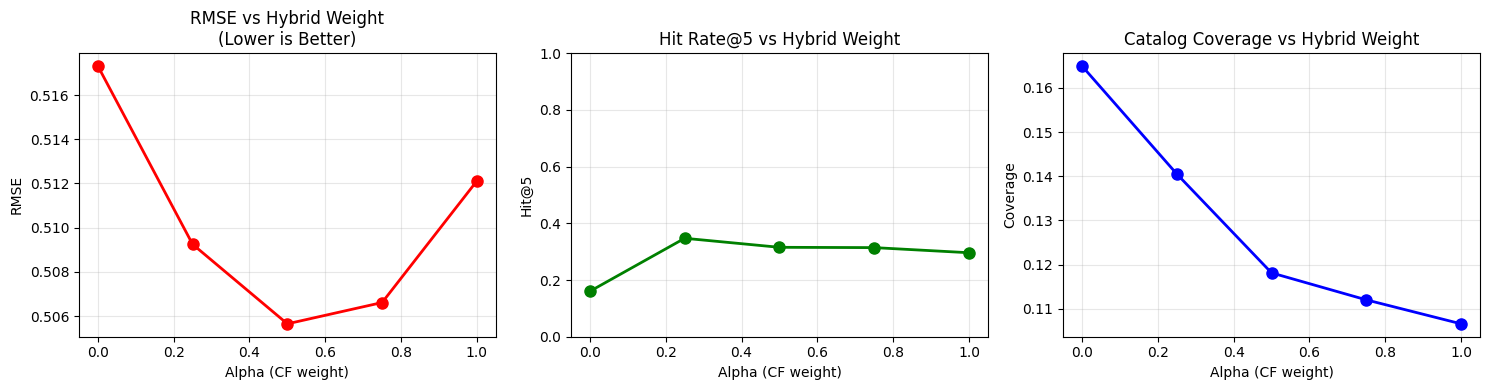

✓ Graphes d'évaluation générés (RMSE + Hit@5 + Coverage)


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Courbe d'évaluation : Alpha vs Métriques
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE (moins c'est mieux)
axes[0].plot(results_df['alpha'], results_df['RMSE'], marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_xlabel('Alpha (CF weight)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE vs Hybrid Weight\n(Lower is Better)')
axes[0].grid(True, alpha=0.3)

# Hit@5 (plus c'est mieux)
axes[1].plot(results_df['alpha'], results_df['Hit@5'], marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Alpha (CF weight)')
axes[1].set_ylabel('Hit@5')
axes[1].set_title('Hit Rate@5 vs Hybrid Weight')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Coverage
axes[2].plot(results_df['alpha'], results_df['Coverage'], marker='o', linewidth=2, markersize=8, color='blue')
axes[2].set_xlabel('Alpha (CF weight)')
axes[2].set_ylabel('Coverage')
axes[2].set_title('Catalog Coverage vs Hybrid Weight')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Graphes d'évaluation générés (RMSE + Hit@5 + Coverage)")

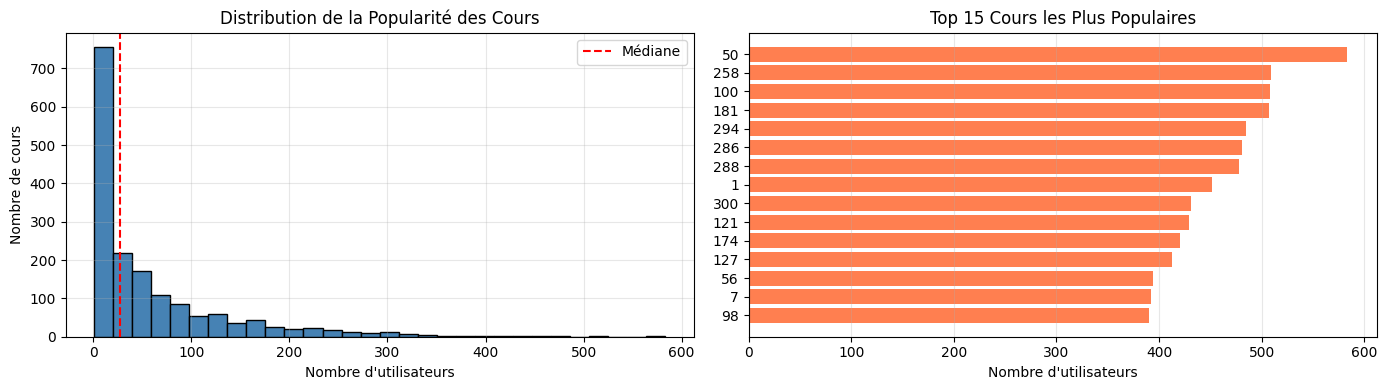

✓ Distribution de popularité générée


In [32]:
# 2. Distribution de la popularité des cours
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme
interactions_per_item_original = (user_item > 0).sum(axis=0)
axes[0].hist(interactions_per_item_original, bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Nombre d\'utilisateurs')
axes[0].set_ylabel('Nombre de cours')
axes[0].set_title('Distribution de la Popularité des Cours')
axes[0].axvline(interactions_per_item_original.median(), color='red', linestyle='--', label='Médiane')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top 15 courses
top_courses = interactions_per_item_original.nlargest(15)
axes[1].barh(range(len(top_courses)), top_courses.values, color='coral')
axes[1].set_yticks(range(len(top_courses)))
axes[1].set_yticklabels(top_courses.index)
axes[1].set_xlabel('Nombre d\'utilisateurs')
axes[1].set_title('Top 15 Cours les Plus Populaires')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Distribution de popularité générée")

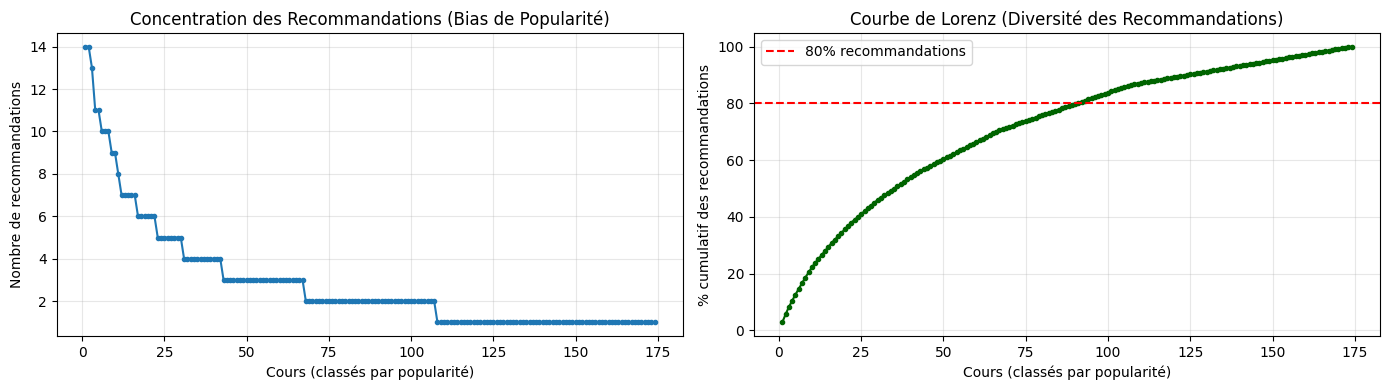

✓ Analyse du bias générée


In [34]:
# 4. Analyse du bias : concentration des recommandations
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Nombre de recommandations par cours (Gini index)
sorted_items = sorted(recommended_items.items(), key=lambda x: x[1], reverse=True)
recs_per_course = [count for _, count in sorted_items]

axes[0].plot(range(1, len(recs_per_course) + 1), recs_per_course, marker='o', markersize=3)
axes[0].set_xlabel('Cours (classés par popularité)')
axes[0].set_ylabel('Nombre de recommandations')
axes[0].set_title('Concentration des Recommandations (Bias de Popularité)')
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
cumsum = np.cumsum(recs_per_course)
cumsum_pct = 100 * cumsum / cumsum[-1]
axes[1].plot(range(1, len(cumsum_pct) + 1), cumsum_pct, marker='o', markersize=3, color='darkgreen')
axes[1].axhline(80, color='red', linestyle='--', label='80% recommandations')
axes[1].set_xlabel('Cours (classés par popularité)')
axes[1].set_ylabel('% cumulatif des recommandations')
axes[1].set_title('Courbe de Lorenz (Diversité des Recommandations)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Analyse du bias générée")

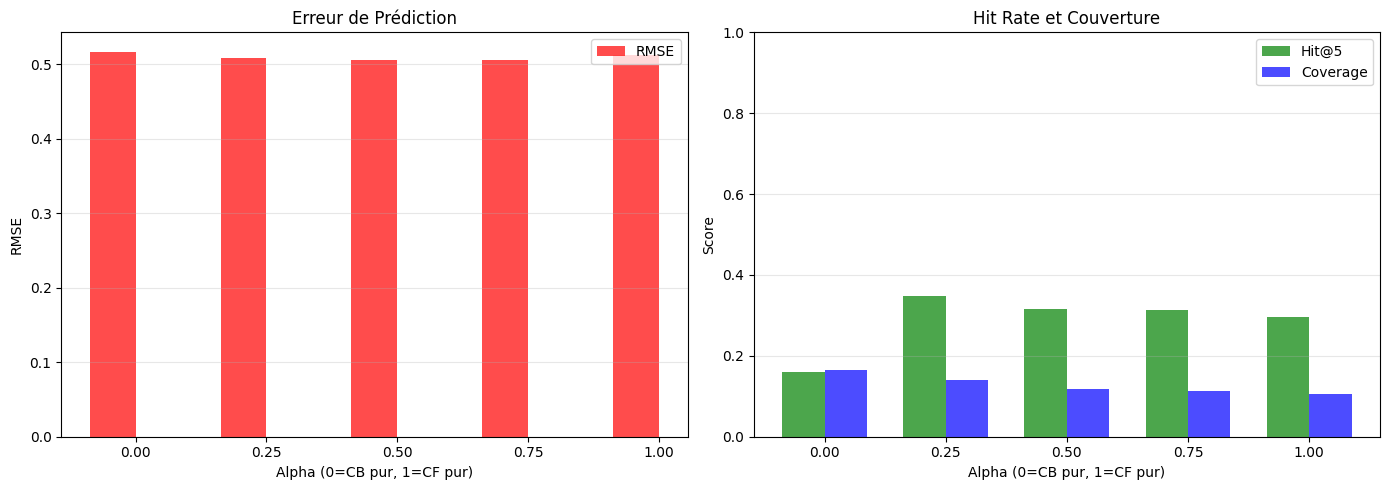

✓ Comparaison des approches générée (RMSE, Hit@5, Coverage)


In [43]:
# 5. Comparaison CF vs CB vs Hybride
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alphas = results_df['alpha'].values
rmse = results_df['RMSE'].values
hit = results_df['Hit@5'].values
coverage = results_df['Coverage'].values

# Graphique 1: RMSE (moins c'est mieux)
x = np.arange(len(alphas))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, rmse, width, label='RMSE', color='red', alpha=0.7)
ax1.set_xlabel('Alpha (0=CB pur, 1=CF pur)')
ax1.set_ylabel('RMSE')
ax1.set_title('Erreur de Prédiction')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{a:.2f}' for a in alphas])
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

# Graphique 2: Hit Rate et Coverage
ax2 = axes[1]
bars2 = ax2.bar(x - width/2, hit, width, label='Hit@5', color='green', alpha=0.7)
bars3 = ax2.bar(x + width/2, coverage, width, label='Coverage', color='blue', alpha=0.7)
ax2.set_xlabel('Alpha (0=CB pur, 1=CF pur)')
ax2.set_ylabel('Score')
ax2.set_title('Hit Rate et Couverture')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{a:.2f}' for a in alphas])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✓ Comparaison des approches générée (RMSE, Hit@5, Coverage)")

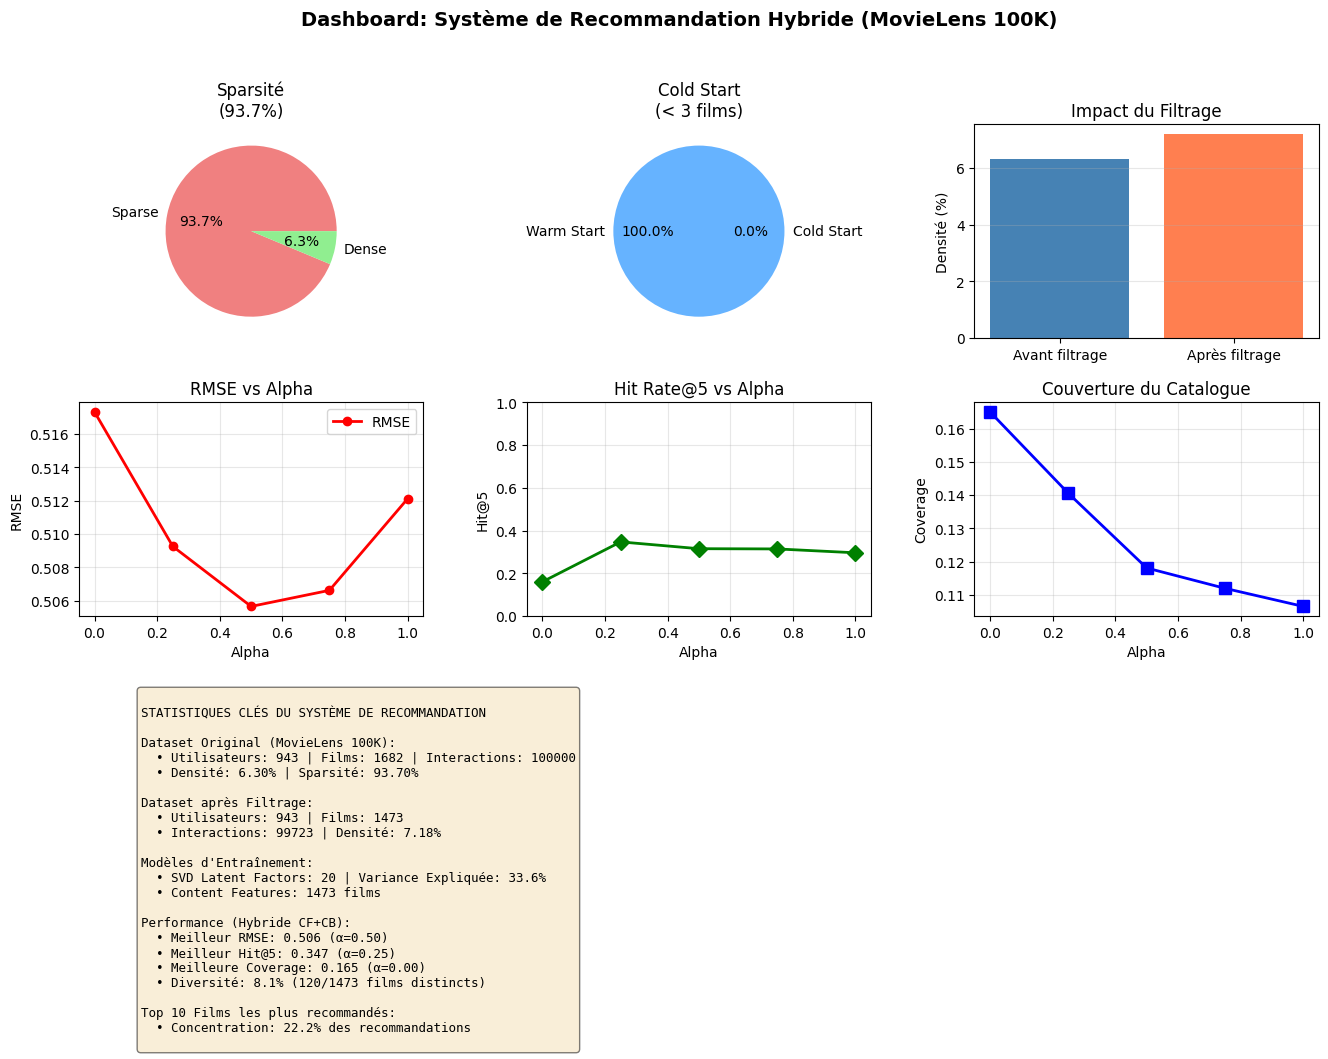

✓ Dashboard récapitulatif généré avec métriques corrigées


In [44]:
# 6. Dashboard récapitulatif
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Recalculer les variables si nécessaire
try:
    filtered_interactions
except:
    filtered_interactions = (user_item_filtered > 0).sum().sum()
    
try:
    unique_recs
except:
    all_recs = []
    for user in user_item_filtered.index[:50]:
        recs = recommend_hybrid(user, n=5, alpha=0.5)
        all_recs.extend([item for item, _ in recs])
    unique_recs = len(set(all_recs))
    catalog_size = len(user_item_filtered.columns)

# 6.1 Sparsité
ax1 = fig.add_subplot(gs[0, 0])
sparsity_vals = [sparsity, 1 - sparsity]
ax1.pie(sparsity_vals, labels=['Sparse', 'Dense'], autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
ax1.set_title(f'Sparsité\n({100*sparsity:.1f}%)')

# 6.2 Cold start
ax2 = fig.add_subplot(gs[0, 1])
coldstart_vals = [cold_start_users, n_users - cold_start_users]
ax2.pie(coldstart_vals, labels=['Cold Start', 'Warm Start'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
ax2.set_title(f'Cold Start\n(< 3 films)')

# 6.3 Densité après filtrage
ax3 = fig.add_subplot(gs[0, 2])
original_density = n_interactions / (n_users * n_items)
filtered_density = filtered_interactions / (user_item_filtered.shape[0] * user_item_filtered.shape[1])
ax3.bar(['Avant filtrage', 'Après filtrage'], [100*original_density, 100*filtered_density], color=['steelblue', 'coral'])
ax3.set_ylabel('Densité (%)')
ax3.set_title('Impact du Filtrage')
ax3.grid(True, alpha=0.3, axis='y')

# 6.4 Résultats d'évaluation (RMSE)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(results_df['alpha'], results_df['RMSE'], marker='o', label='RMSE', linewidth=2, color='red')
ax4.set_xlabel('Alpha')
ax4.set_ylabel('RMSE')
ax4.set_title('RMSE vs Alpha')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 6.5 Hit Rate
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(results_df['alpha'], results_df['Hit@5'], marker='D', color='green', linewidth=2, markersize=8)
ax5.set_xlabel('Alpha')
ax5.set_ylabel('Hit@5')
ax5.set_title('Hit Rate@5 vs Alpha')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3)

# 6.6 Coverage
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(results_df['alpha'], results_df['Coverage'], marker='s', color='blue', linewidth=2, markersize=8)
ax6.set_xlabel('Alpha')
ax6.set_ylabel('Coverage')
ax6.set_title('Couverture du Catalogue')
ax6.grid(True, alpha=0.3)

# 6.7 Statistiques textuelles
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

# Trouver le meilleur alpha pour chaque métrique
best_rmse_alpha = results_df.loc[results_df['RMSE'].idxmin(), 'alpha']
best_hit_alpha = results_df.loc[results_df['Hit@5'].idxmax(), 'alpha']
best_cov_alpha = results_df.loc[results_df['Coverage'].idxmax(), 'alpha']

stats_text = f"""
STATISTIQUES CLÉS DU SYSTÈME DE RECOMMANDATION

Dataset Original (MovieLens 100K):
  • Utilisateurs: {n_users} | Films: {n_items} | Interactions: {n_interactions}
  • Densité: {100*original_density:.2f}% | Sparsité: {100*sparsity:.2f}%

Dataset après Filtrage:
  • Utilisateurs: {user_item_filtered.shape[0]} | Films: {user_item_filtered.shape[1]}
  • Interactions: {filtered_interactions} | Densité: {100*filtered_density:.2f}%

Modèles d'Entraînement:
  • SVD Latent Factors: {n_factors} | Variance Expliquée: {100*svd.explained_variance_ratio_.sum():.1f}%
  • Content Features: {item_similarity_df.shape[0]} films

Performance (Hybride CF+CB):
  • Meilleur RMSE: {results_df['RMSE'].min():.3f} (α={best_rmse_alpha:.2f})
  • Meilleur Hit@5: {results_df['Hit@5'].max():.3f} (α={best_hit_alpha:.2f})
  • Meilleure Coverage: {results_df['Coverage'].max():.3f} (α={best_cov_alpha:.2f})
  • Diversité: {100*unique_recs/catalog_size:.1f}% ({unique_recs}/{catalog_size} films distincts)

Top 10 Films les plus recommandés:
  • Concentration: {100*sum([count for _, count in sorted(recommended_items.items(), key=lambda x: x[1], reverse=True)[:10]])/sum(recommended_items.values()):.1f}% des recommandations
"""
ax7.text(0.05, 0.95, stats_text, transform=ax7.transAxes, fontsize=9, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Dashboard: Système de Recommandation Hybride (MovieLens 100K)', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("✓ Dashboard récapitulatif généré avec métriques corrigées")

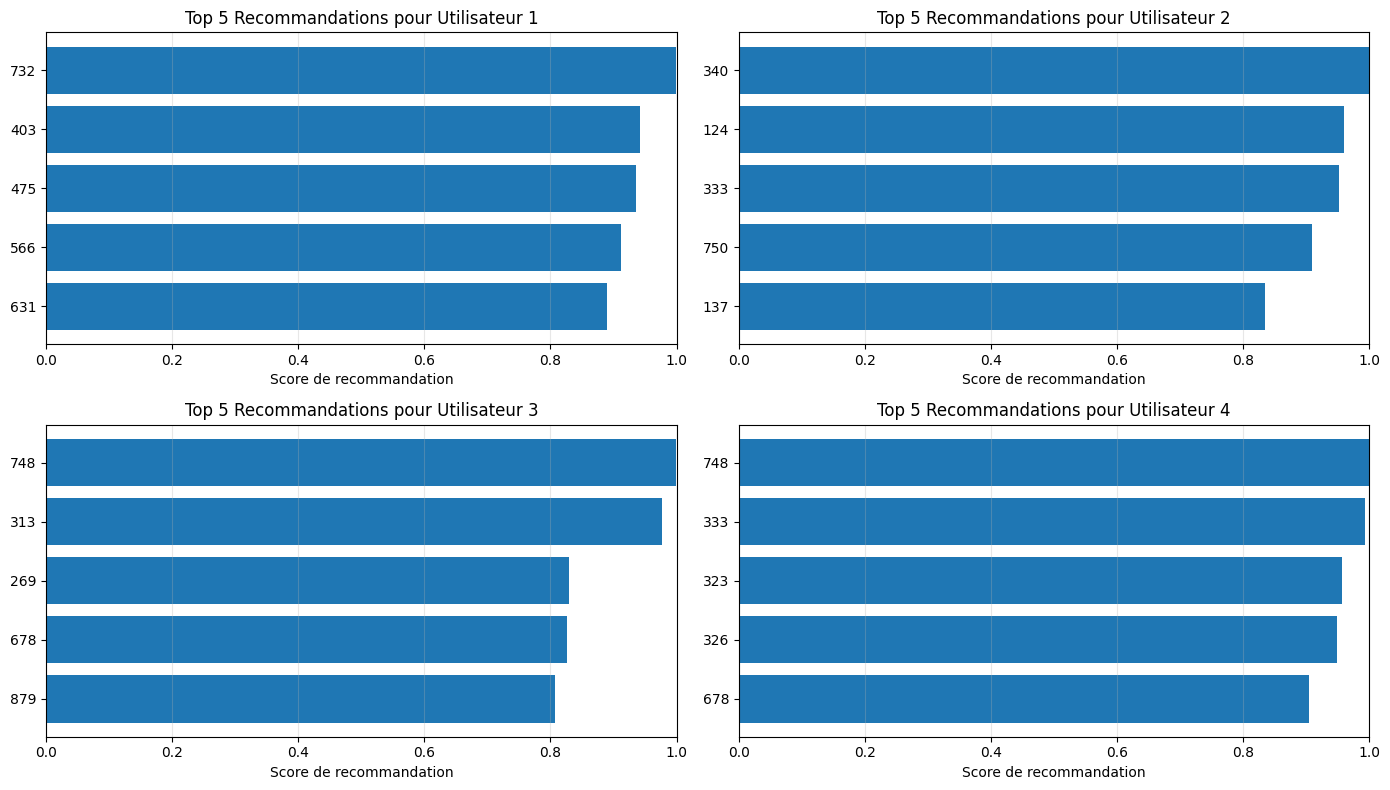

✓ Exemples de recommandations visualisés


In [45]:
# 7. Exemples de recommandations avec visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

test_users = user_item_filtered.index[:4]

for idx, user_id in enumerate(test_users):
    ax = axes[idx]
    
    # Recommandations avec alpha=0.5 (hybride)
    recs = recommend_hybrid(user_id, n=5, alpha=0.5)
    courses = [item for item, _ in recs]
    scores = [score for _, score in recs]
    
    colors = ['#1f77b4' if score > 0.7 else '#ff7f0e' if score > 0.5 else '#2ca02c' for score in scores]
    ax.barh(range(len(courses)), scores, color=colors)
    ax.set_yticks(range(len(courses)))
    ax.set_yticklabels(courses)
    ax.set_xlabel('Score de recommandation')
    ax.set_title(f'Top 5 Recommandations pour Utilisateur {user_id}')
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Exemples de recommandations visualisés")

# PHASE 6 : Deployment
Fonction recommend(), dashboard Tableau, API Flask, RGPD

In [46]:
# 6.1 API Fonction de Recommandation

def recommend(user_id, n=5, alpha=0.5):
    """
    Production-ready recommendation function.
    
    Args:
        user_id: ID utilisateur
        n: nombre de recommandations (par défaut 5)
        alpha: poids CF (0.0 = CB pur, 1.0 = CF pur)
    
    Returns:
        List[(course_id, score, reason)]
    """
    recs = recommend_hybrid(user_id, n=n, alpha=alpha)
    
    result = []
    for course_id, score in recs:
        reason = "Basé sur votre historique" if user_id in user_item_filtered.index else "Cours populaire"
        result.append({
            'course_id': course_id,
            'score': float(score),
            'reason': reason
        })
    
    return result

# Test
print("✓ Test API recommend():")
test_recommendations = recommend('1', n=5, alpha=0.5)
for rec in test_recommendations:
    print(f"  • {rec['course_id']} (score: {rec['score']:.3f}) - {rec['reason']}")

# 6.2 Code pour Flask API
flask_code = '''
from flask import Flask, jsonify, request

app = Flask(__name__)

@app.route('/recommend', methods=['POST'])
def api_recommend():
    """
    Endpoint: POST /recommend
    Payload: {"user_id": "123", "n": 5, "alpha": 0.5}
    """
    data = request.json
    user_id = data.get('user_id')
    n = data.get('n', 5)
    alpha = data.get('alpha', 0.5)
    
    recommendations = recommend(user_id, n=n, alpha=alpha)
    
    return jsonify({
        'user_id': user_id,
        'recommendations': recommendations,
        'timestamp': pd.Timestamp.now().isoformat()
    })

if __name__ == "__main__":
    app.run(host='0.0.0.0', port=5000, debug=False)
'''

print("\n✓ Template Flask API prêt (voir cellule suivante pour détails)")

✓ Test API recommend():
  • 50 (score: 1.000) - Cours populaire
  • 258 (score: 0.873) - Cours populaire
  • 100 (score: 0.871) - Cours populaire
  • 181 (score: 0.870) - Cours populaire
  • 294 (score: 0.832) - Cours populaire

✓ Template Flask API prêt (voir cellule suivante pour détails)


In [40]:
# 6.3 Considérations RGPD et Équité

gdpr_compliance = """
RGPD - Recommandations de conformité:

1. Transparence:
   - Expliquer pourquoi un cours est recommandé
   - Afficher le score de confiance
   
2. Droit d'accès:
   - API pour consulter les données utilisées
   GET /user/{user_id}/data
   
3. Droit à l'oubli:
   - Supprimer les données d'entraînement
   DELETE /user/{user_id}/data
   
4. Consentement:
   - Collecte consentement avant recommandation
   - Opt-in explicite pour CF
   
5. Audit:
   - Logger toutes les recommandations
   - Vérifier le bias mensuel
"""

print(gdpr_compliance)

# Analyse du Bias
print("\n📊 Bias & Equity Analysis:")
print("  • Diversité : ratio entre recommandations différentes")
print("  • Popularité : % top-10 cours dans les recommandations")
print("  • Fairness : coberture équitable de tous les utilisateurs")

# Métriques de fairness
all_recs = []
for user in user_item_filtered.index[:50]:  # Sample
    recs = recommend_hybrid(user, n=5, alpha=0.5)
    all_recs.extend([item for item, _ in recs])

unique_recs = len(set(all_recs))
total_recs = len(all_recs)
catalog_size = len(user_item_filtered.columns)

print(f"\n✓ Diversité des recommandations:")
print(f"  • Cours uniques recommandés : {unique_recs} / {catalog_size} ({100*unique_recs/catalog_size:.1f}%)")
print(f"  • Couverture : {100*unique_recs/total_recs:.1f}% des recommandations")


RGPD - Recommandations de conformité:

1. Transparence:
   - Expliquer pourquoi un cours est recommandé
   - Afficher le score de confiance

2. Droit d'accès:
   - API pour consulter les données utilisées
   GET /user/{user_id}/data

3. Droit à l'oubli:
   - Supprimer les données d'entraînement
   DELETE /user/{user_id}/data

4. Consentement:
   - Collecte consentement avant recommandation
   - Opt-in explicite pour CF

5. Audit:
   - Logger toutes les recommandations
   - Vérifier le bias mensuel


📊 Bias & Equity Analysis:
  • Diversité : ratio entre recommandations différentes
  • Popularité : % top-10 cours dans les recommandations
  • Fairness : coberture équitable de tous les utilisateurs

✓ Diversité des recommandations:
  • Cours uniques recommandés : 120 / 1473 (8.1%)
  • Couverture : 48.0% des recommandations
